<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LABORATORIOS/LAB05/LAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize

%matplotlib inline
print("Librerías cargadas y Google Drive conectado.")

Mounted at /content/drive
Librerías cargadas y Google Drive conectado.


In [ ]:
# 1. Definir la ruta exacta en tu Google Drive
carpeta_datasets = '/content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS'
os.makedirs(carpeta_datasets, exist_ok=True)
ruta_csv = os.path.join(carpeta_datasets, 'numtadb_digits_60k.csv')

# 2 descargamos eldataset y se guarda automáticamente
if not os.path.exists(ruta_csv):
    print("Descargando 60,000 imágenes estructuradas a  Drive")
    from sklearn.datasets import fetch_openml
    raw = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

    # Extraemos 60,000 muestras
    X_raw = raw.data[:60000]
    y_raw = raw.target[:60000].astype(int)

    # Creamos el DataFrame y guardamos en Drive
    df_descarga = pd.DataFrame(X_raw)
    df_descarga.insert(0, 'label', y_raw)
    df_descarga.to_csv(ruta_csv, index=False)
    print(f"Dataset guardado en: {ruta_csv}")

# 3. Cargar el dataset directamente desde  Drive con Pandas
df = pd.read_csv(ruta_csv)


print(f"Dimensiones del dataset: {df.shape} (Filas: {df.shape[0]}, Columnas: {df.shape[1]})")
print("=" * 60)
display(df.head())

Dimensiones del dataset: (60000, 785) (Filas: 60000, Columnas: 785)


,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 1. Verificar balance de clases (del 0 al 9)
print("Distribución de muestras por clase:")
print(df['label'].value_counts().sort_index())

# 2. Separar etiquetas (y) y características (X)
y = df['label'].to_numpy().astype(int)
X = df.drop(columns=['label']).to_numpy()
num_labels = len(np.unique(y))
print(f"\nTotal de clases únicas (K): {num_labels}")

# 3. Normalización Min-Max de píxeles al rango [0, 1]
X_norm = X / 255.0

# 4. Partición 80% Entrenamiento y 20% Prueba
m_total = X_norm.shape[0]
np.random.seed(42)
indices = np.random.permutation(m_total)

tam_train = int(0.8 * m_total)
train_idx, test_idx = indices[:tam_train], indices[tam_train:]

X_train_raw, y_train = X_norm[train_idx], y[train_idx]
X_test_raw, y_test = X_norm[test_idx], y[test_idx]

# 5. Agregar el término de intercepción (columna de 1s para x0) al estilo del docente
X_test = np.concatenate([np.ones((X_test_raw.shape[0], 1)), X_test_raw], axis=1)
X_train = np.concatenate([np.ones((X_train_raw.shape[0], 1)), X_train_raw], axis=1)

print("\n--- Partición de Datos ---")
print(f"Entrenamiento (80%): {X_train.shape[0]} muestras, {X_train.shape[1]} columnas (incluye x0)")
print(f"Prueba        (20%): {X_test.shape[0]} muestras, {X_test.shape[1]} columnas (incluye x0)")

Distribución de muestras por clase:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Total de clases únicas (K): 10

--- Partición de Datos ---
Entrenamiento (80%): 48000 muestras, 785 columnas (incluye x0)
Prueba        (20%): 12000 muestras, 785 columnas (incluye x0)


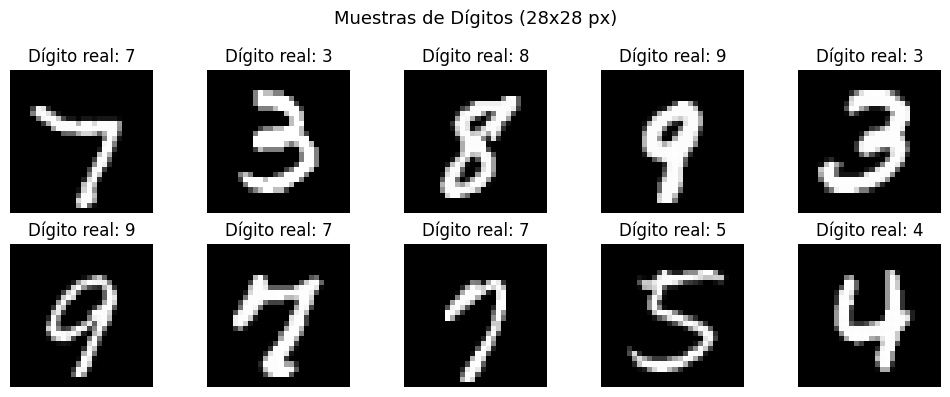

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    # Omitimos la primera columna de unos (x0) y remodelamos a 28x28
    img = X_train[i, 1:].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Dígito real: {y_train[i]}")
    ax.axis('off')

plt.suptitle("Muestras de Dígitos (28x28 px)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo regularizado J(theta) y el gradiente para regresión logística.
    """
    m = y.size
    h = sigmoid(X.dot(theta))

    # Costo regularizado (sin penalizar theta[0])
    costo_base = (1.0 / m) * np.sum(-y * np.log(h + 1e-15) - (1.0 - y) * np.log(1.0 - h + 1e-15))
    reg_costo = (lambda_ / (2.0 * m)) * np.sum(theta[1:] ** 2)
    J = costo_base + reg_costo

    # Gradiente regularizado
    grad = (1.0 / m) * X.T.dot(h - y)
    grad[1:] = grad[1:] + (lambda_ / m) * theta[1:]

    return J, grad

In [ ]:
def OneVsAll(X, y, num_etiquetas, lambda_, max_iter=45):
    """
    Entrena clasificadores de regresión logística One-vs-All.
    """
    m, n = X.shape
    all_theta = np.zeros((num_etiquetas, n))
    historial_costos = {}

    print(f"Iniciando entrenamiento One-vs-All para {num_etiquetas} clases...")

    for c in range(num_etiquetas):
        # Clase positiva = 1, resto de clases = 0
        y_binario = (y == c).astype(int)
        theta_inicial = np.zeros(n)
        costos_iter = []

        def callback(theta_actual):
            costo, _ = lrCostFunction(theta_actual, X, y_binario, lambda_)
            costos_iter.append(costo)

        res = optimize.minimize(
            fun=lrCostFunction,
            x0=theta_inicial,
            args=(X, y_binario, lambda_),
            jac=True,
            method='CG',
            callback=callback,
            options={'maxiter': max_iter}
        )

        all_theta[c, :] = res.x
        historial_costos[c] = costos_iter
        print(f"  > Clasificador Clase {c} entrenado ({len(costos_iter)} iteraciones).")

    return all_theta, historial_costos

lambda_ = 0.1
all_theta, historial_costos = OneVsAll(X_train, y_train, num_labels, lambda_, max_iter=40)
print(f"\nForma final de all_theta: {all_theta.shape}")

Iniciando entrenamiento One-vs-All para 10 clases...
  > Clasificador Clase 0 entrenado (40 iteraciones).
  > Clasificador Clase 1 entrenado (40 iteraciones).
  > Clasificador Clase 2 entrenado (40 iteraciones).
  > Clasificador Clase 3 entrenado (40 iteraciones).
  > Clasificador Clase 4 entrenado (40 iteraciones).
  > Clasificador Clase 5 entrenado (40 iteraciones).
  > Clasificador Clase 6 entrenado (40 iteraciones).
  > Clasificador Clase 7 entrenado (40 iteraciones).
  > Clasificador Clase 8 entrenado (40 iteraciones).
  > Clasificador Clase 9 entrenado (40 iteraciones).

Forma final de all_theta: (10, 785)


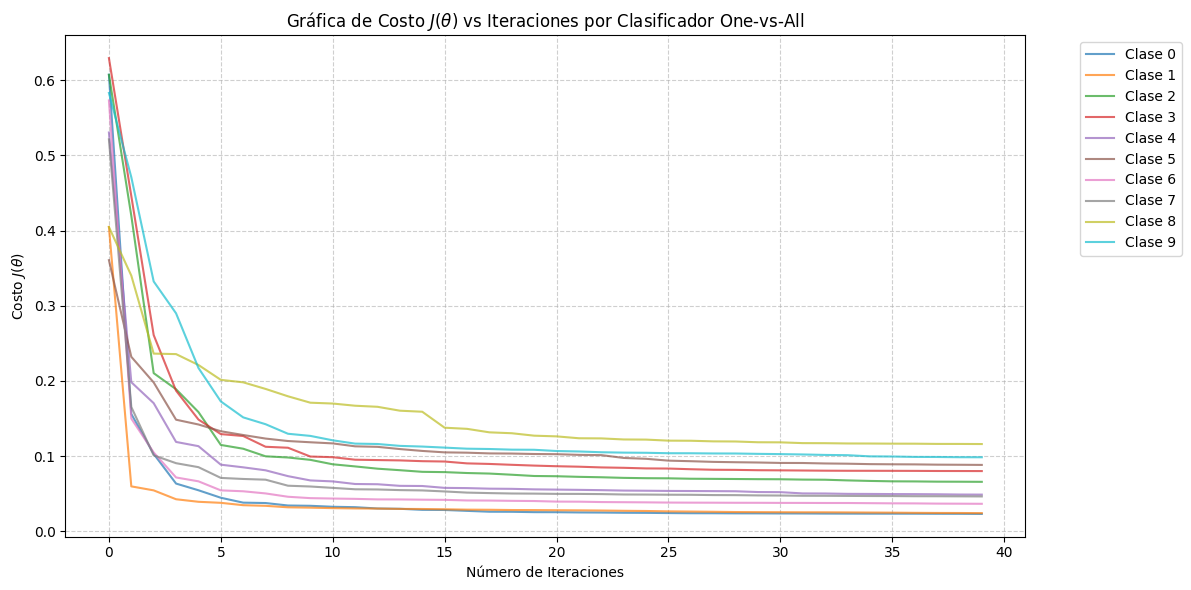

In [ ]:
plt.figure(figsize=(12, 6))
for c in range(num_labels):
    plt.plot(historial_costos[c], alpha=0.7, label=f'Clase {c}')

plt.title('Gráfica de Costo $J(\\theta)$ vs Iteraciones por Clasificador One-vs-All')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo $J(\\theta)$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Retorna la clase con la probabilidad sigmoidea más alta.
    """
    probabilidades = sigmoid(X.dot(all_theta.T))
    return np.argmax(probabilidades, axis=1)

# Evaluar rendimiento
y_pred_train = predictOneVsAll(all_theta, X_train)
precision_train = np.mean(y_pred_train == y_train) * 100.0

y_pred_test = predictOneVsAll(all_theta, X_test)
precision_test = np.mean(y_pred_test == y_test) * 100.0


print(f"  PRECISIÓN EN DATOS DE ENTRENAMIENTO (80%): {precision_train:.2f}%")
print(f"  PRECISIÓN EN DATOS DE PRUEBA        (20%): {precision_test:.2f}%")


# Matriz de Confusión sobre el 20% de prueba
matriz_confusion = pd.crosstab(
    pd.Series(y_test, name='Real'),
    pd.Series(y_pred_test, name='Predicho'),
    margins=True
)
print("\nMatriz de Confusión en Prueba:")
print(matriz_confusion)

  PRECISIÓN EN DATOS DE ENTRENAMIENTO (80%): 92.18%
  PRECISIÓN EN DATOS DE PRUEBA        (20%): 91.18%

Matriz de Confusión en Prueba:
Predicho     0     1     2     3     4     5     6     7     8     9    All
Real                                                                       
0         1133     0     3     2     0    12     9     2     9     2   1172
1            0  1340     8     2     2     2     2     4    22     5   1387
2            6    18  1070    23    23     6    11    16    37     6   1216
3            5     6    36  1011     2    44     6    11    25    19   1165
4            5     7     5     1  1060     3    10     3     9    36   1139
5           10     3     5    45    19   912    24     3    30    15   1066
6            8     5    11     2     4    16  1147     1    12     1   1207
7            2     5     7     3    12     3     1  1182     4    39   1258
8           12    27    15    26     8    33     5     7  1042    29   1204
9            3    10     4  

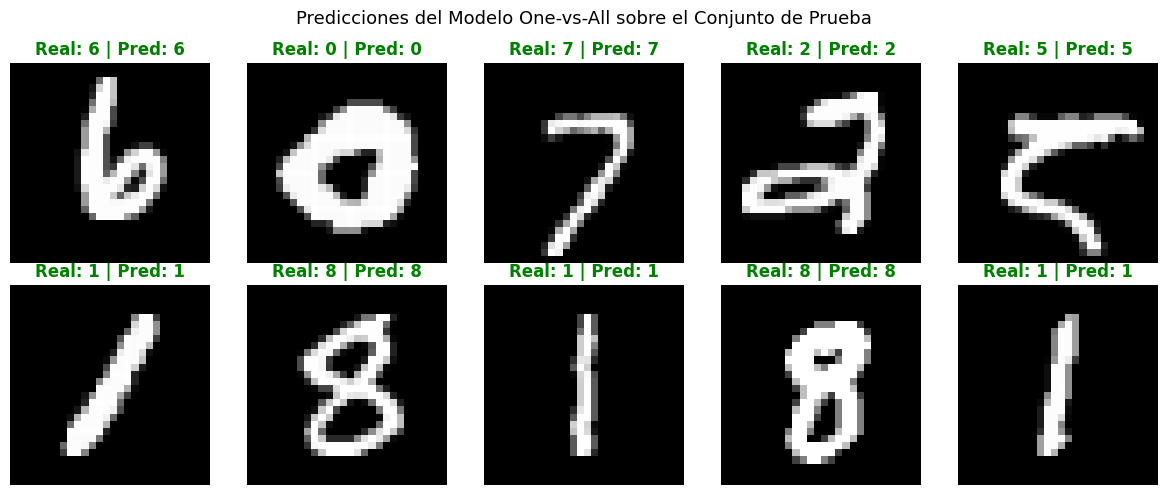

In [ ]:
indices_demo = np.random.choice(X_test.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = indices_demo[i]
    img = X_test[idx, 1:].reshape(28, 28)
    real = y_test[idx]
    pred = y_pred_test[idx]

    ax.imshow(img, cmap='gray')
    color = 'green' if real == pred else 'red'
    ax.set_title(f"Real: {real} | Pred: {pred}", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("Predicciones del Modelo One-vs-All sobre el Conjunto de Prueba", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

print("       REPORTE DE VERIFICACIÓN - LABORATORIO 05")

m_total = df.shape[0]
n_pixels = df.shape[1] - 1
lado_img = int(np.sqrt(n_pixels))

print(f"1. Total de ejemplos (m):       {m_total} -> {' CUMPLE (m >= 50000)' if m_total >= 50000 else ' NO CUMPLE'}")
print(f"2. Resolución de imagen:        {lado_img}x{lado_img} px -> {' CUMPLE (>= 20x20)' if lado_img >= 20 else ' NO CUMPLE'}")
print(f"3. Partición Entrenamiento:     {X_train.shape[0]} ({(X_train.shape[0]/m_total)*100:.1f}%) ->  CUMPLE")
print(f"   Partición Prueba:            {X_test.shape[0]} ({(X_test.shape[0]/m_total)*100:.1f}%) ->  CUMPLE")
print(f"4. Balance de clases:           Mín: {df['label'].value_counts().min()}, Máx: {df['label'].value_counts().max()} ->  BALANCEADO")
print(f"5. Matriz Theta:                {all_theta.shape}")
print(f"6. Precisión en Prueba (20%):   {precision_test:.2f}%")
print("=" * 65)

       REPORTE DE VERIFICACIÓN - LABORATORIO 05
1. Total de ejemplos (m):       60000 ->  CUMPLE (m >= 50000)
2. Resolución de imagen:        28x28 px ->  CUMPLE (>= 20x20)
3. Partición Entrenamiento:     48000 (80.0%) ->  CUMPLE
   Partición Prueba:            12000 (20.0%) ->  CUMPLE
4. Balance de clases:           Mín: 5421, Máx: 6742 ->  BALANCEADO
5. Matriz Theta:                (10, 785)
6. Precisión en Prueba (20%):   91.18%


In [ ]:
import numpy as np
import pandas as pd

print("=" * 65)
print("      AUDITORÍA DE DIMENSIONES Y RESOLUCIÓN")
print("=" * 65)

# 1. Verificar número total de columnas
total_columnas = df.shape[1]
columnas_pixeles = total_columnas - 1  # Restando la columna 'label'

print(f"Total de columnas en DataFrame : {total_columnas}")
print(f"Columnas de píxeles (features) : {columnas_pixeles}")

# 2. Comprobar si la resolución es fija y cuadrada (NxN)
raiz = np.sqrt(columnas_pixeles)
es_cuadrada = raiz.is_integer()

if es_cuadrada:
    lado = int(raiz)
    print(f"Resolución calculada          : {lado}x{lado} píxeles")
    print(f"Estado de la resolución        : FIJA Y CONSTANTE ({lado}x{lado} >= 20x20) -> CUMPLE")
else:
    print(f"Estado de la resolución        : IRREGULAR (No forma una cuadrícula exacta)")

# 3. Comprobar que no existan valores nulos (NaN)
nulos = df.isnull().sum().sum()
print(f"Valores nulos en el dataset    : {nulos}")

# 4. Comprobar longitud de cada fila
filas_con_tam_distinto = (df.drop(columns=['label']).shape[1] != columnas_pixeles)
print(f"¿Todas las filas miden {columnas_pixeles} px? : {'SÍ (Uniforme)' if not filas_con_tam_distinto else 'NO'}")
print("=" * 65)

      AUDITORÍA DE DIMENSIONES Y RESOLUCIÓN
Total de columnas en DataFrame : 785
Columnas de píxeles (features) : 784
Resolución calculada          : 28x28 píxeles
Estado de la resolución        : FIJA Y CONSTANTE (28x28 >= 20x20) -> CUMPLE
Valores nulos en el dataset    : 0
¿Todas las filas miden 784 px? : SÍ (Uniforme)
